In [1]:
pip install pandas textblob matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
!python -m textblob.download_corpora

[nltk_data] Downloading package brown to /Users/akachi/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/akachi/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /Users/akachi/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/akachi/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to
[nltk_data]     /Users/akachi/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to
[nltk_data]     /Users/akachi/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


In [3]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("product_reviews_dataset.csv")

df.head()

,ReviewID,Product,Rating,ReviewText,ReviewDate
0,1,Phone Y,1,Poor quality and bad performance,2025-04-30
1,2,Laptop Air,4,Battery life is fantastic,2025-05-03
2,3,Laptop Air,5,Works better than expected,2025-10-30
3,4,Wireless Earbuds,1,I regret buying this,2025-03-15
4,5,Laptop Air,1,The product feels cheap,2025-12-09


In [5]:
# Number of reviews per product
df["Product"].value_counts()

Product
Phone X             185
Wireless Earbuds    177
Smart Watch         172
Laptop Air          166
Laptop Pro          155
Phone Y             145
Name: count, dtype: int64

In [7]:
# Avg rating per product
df.groupby("Product")["Rating"].mean().sort_values(ascending=False)

Product
Phone Y             3.124138
Laptop Pro          3.051613
Laptop Air          3.030120
Wireless Earbuds    3.022599
Smart Watch         3.005814
Phone X             3.000000
Name: Rating, dtype: float64

In [8]:
# ratings distribution
df["Rating"].value_counts()

Rating
2    217
4    215
5    198
3    191
1    179
Name: count, dtype: int64

In [9]:
# Perform Sentiment Analysis

def get_sentiment(text):

    analysis = TextBlob(text)

    polarity = analysis.sentiment.polarity

    if polarity > 0:
        return "Positive"
    
    elif polarity < 0:
        return "Negative"
    
    else:
        return "Neutral"

In [10]:
df["Sentiment"] = df["ReviewText"].apply(get_sentiment)

df

,ReviewID,Product,Rating,ReviewText,ReviewDate,Sentiment
0,1,Phone Y,1,Poor quality and bad performance,2025-04-30,Negative
1,2,Laptop Air,4,Battery life is fantastic,2025-05-03,Positive
2,3,Laptop Air,5,Works better than expected,2025-10-30,Positive
3,4,Wireless Earbuds,1,I regret buying this,2025-03-15,Neutral
4,5,Laptop Air,1,The product feels cheap,2025-12-09,Positive
...,...,...,...,...,...,...
995,996,Laptop Pro,2,Poor quality and bad performance,2025-06-22,Negative
996,997,Phone Y,4,"Excellent product, works perfectly",2025-05-13,Positive
997,998,Phone Y,4,Works better than expected,2025-03-30,Positive
998,999,Smart Watch,4,Battery life is fantastic,2025-10-26,Positive


In [11]:

# Analyze Sentiment Distribution
sen=df["Sentiment"].value_counts()
sen

Sentiment
Positive    641
Negative    238
Neutral     121
Name: count, dtype: int64

In [12]:
total_sen=df['Sentiment'].value_counts().sum()
total_sen

1000

In [13]:
posi=(sen[0]/total_sen)*100
posi

/var/folders/s0/w02yyjh94xz52j1chq8yv54c0000gn/T/ipykernel_7342/53332509.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  posi=(sen[0]/total_sen)*100


64.1

In [14]:
nega=(sen[1]/total_sen)*100
nega

/var/folders/s0/w02yyjh94xz52j1chq8yv54c0000gn/T/ipykernel_7342/2453257875.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nega=(sen[1]/total_sen)*100


23.799999999999997

In [16]:

# Sentiment by Product
sentiment_product = df.groupby(["Product","Sentiment"]).size().reset_index(name="Count")

sentiment_product

,Product,Sentiment,Count
0,Laptop Air,Negative,31
1,Laptop Air,Neutral,22
2,Laptop Air,Positive,113
3,Laptop Pro,Negative,41
4,Laptop Pro,Neutral,20
5,Laptop Pro,Positive,94
6,Phone X,Negative,43
7,Phone X,Neutral,26
8,Phone X,Positive,116
9,Phone Y,Negative,35


In [17]:
# Sentiment vs Rating
df.groupby("Sentiment")["Rating"].mean()

Sentiment
Negative    1.857143
Neutral     2.016529
Positive    3.666147
Name: Rating, dtype: float64

In [18]:
# Convert ReviewDate to Date Format
df["ReviewDate"] = pd.to_datetime(df["ReviewDate"])

In [19]:
# Reviews Over Time
reviews_time = df.groupby(df["ReviewDate"].dt.month).size()

reviews_time

ReviewDate
1      86
2      68
3      95
4      69
5     107
6      82
7      83
8      74
9      76
10     88
11     86
12     86
dtype: int64

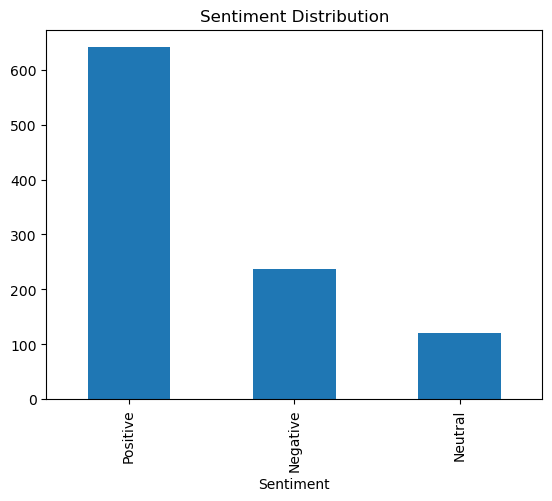

In [20]:

# Sentiment distribution
df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")

plt.show()

In [21]:
df.to_csv("review_sentiment_clean.csv", index=False)